# Linear Elastic PLAXIS model vs Kirsch

In [1]:
# --- PARAMETERS ---
# activate kernel in terminal: myenv\Scripts\activate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

print("READ THE WELLBORE STABILTY DOCUMENT TO FIND OUT WHY STABLE MEANS SIGH")
# https://dnicolasespinoza.github.io/node8.html 
# The code in PLAXIS has somehow done the calculations for unsaturated soil. Check the water table height.z
# 
# What goes wrong here in the code is that the values of plaxis are not effective stresses!!!!
# that is why the results are so different 

READ THE WELLBORE STABILTY DOCUMENT TO FIND OUT WHY STABLE MEANS SIGH


In [2]:
# Geometry
R = 0.25   # borehole radius [m] In the calculations further 'a' will be the radius

# In-situ effective stresses (same as your PLAXIS model)
z = 6       # must be the same as what you analyse in plaxis
gamma_s = 20
gamma_w = 10
K0 = 0.5

sigv = z * (gamma_s - gamma_w)   # vertical effective stress
sigh = K0 * sigv                 # horizontal effective stress
sigH = sigh                      # same in your model

# Material
nu = 0.3

# Load steps (from 100% to 0% to simulate excavation/unloading) (excluding phase0)
lf = np.arange(1, -0.1, -0.1) 

n_phases = len(lf) # total number of phases including phase0
phase_names = [f'phase{i+1}' for i in range(n_phases)]

# Borehole pressure (20 could be added as a minimum value of deltaPw for the rule of thumb used in real life drilling)
# deltaPw = Pw - Pp. The formula below is working in effective stress so we do not have to remove the pore pressure, making the formula simpler

deltaPw = sigh * lf  # As in time soil is removed the sigh is reduced which is why it is multiplied by lf. Pw eventually becomes only Pp

# File
file_path = './ResultsLinearSimpleRun/ResultsLinearSimpleRun_LinearElastic.xlsx'

In [3]:
# --- KIRSCH SOLUTION ---

def kirsch(r, theta, a, sigH, sigh, sigv, deltaPw, nu):
    # r is distance from borehole wall. So at borehol wall r=a, a is borehole radius
    term1 = deltaPw * (a**2 / r**2)
    
    # values negative because of sign convention in PLAXIS (tension positive) vs Kirsch (tension negative)
    sigma_rr = term1 + \
        (sigH + sigh)/2 * (1 - a**2/r**2) + \
        (sigH - sigh)/2 * (1 - 4*a**2/r**2 + 3*a**4/r**4) * np.cos(2*theta) # radial

    sigma_tt = -term1 + \
        (sigH + sigh)/2 * (1 + a**2/r**2) - \
        (sigH - sigh)/2 * (1 + 3*a**4/r**4) * np.cos(2*theta)   # hoop (tangential)

    tau_rt = - (sigH - sigh)/2 * \
        (1 + 2*a**2/r**2 - 3*a**4/r**4) * np.sin(2*theta) # rotational shear

    sigma_zz = sigv - 2 * nu * (sigH - sigh) * (a**2 / r**2) * np.cos(2*theta)

    return sigma_rr, sigma_tt, tau_rt, sigma_zz

In [4]:
# --- LOAD DATA + CONVERT TO POLAR STRESSES ---
# Values in plaxis are negative for compression

results = {}

for i, phase in enumerate(phase_names):
    df = pd.read_excel(file_path, sheet_name=phase)

    # Coordinates
    x = df['x'].values
    y = df['y'].values

    r = np.sqrt(x**2 + y**2) # distance from borehole wall at 45 degrees angle
    theta = np.arctan2(y, x)

    # Cartesian stresses
    sigx = df['sigx'].values
    sigy = df['sigy'].values
    sigxy = df['sigxy'].values

    # Convert to polar (and apply sign convention for tension negative and compression positive)
    sigma_rr = -(sigx * np.cos(theta)**2 +
                sigy * np.sin(theta)**2 +
                2 * sigxy * np.sin(theta) * np.cos(theta))

    sigma_tt = -(sigx * np.sin(theta)**2 +
                sigy * np.cos(theta)**2 -
                2 * sigxy * np.sin(theta) * np.cos(theta))

    tau_rt = -((sigy - sigx) * np.sin(theta) * np.cos(theta) +
              sigxy * (np.cos(theta)**2 - np.sin(theta)**2))

  # Pw values
    dPw = deltaPw[i]

    # Kirsch
    sig_rr_k = []
    sig_tt_k = []
    tau_rt_k = []

    for j in range(len(r)):
        srr, stt, trt, _ = kirsch(r[j], theta[j], R, sigH, sigh, sigv, deltaPw[i], nu)
        sig_rr_k.append(srr)
        sig_tt_k.append(stt)
        tau_rt_k.append(trt)

    # Store
    df['r'] = r
    df['sig_rr_plx'] = sigma_rr
    df['sig_tt_plx'] = sigma_tt
    df['tau_rt_plx'] = tau_rt

    df['sig_rr_k'] = sig_rr_k
    df['sig_tt_k'] = sig_tt_k
    df['tau_rt_k'] = tau_rt_k

    df = df.sort_values(by='r')

    results[phase] = df
# print(results['phase1'].head())

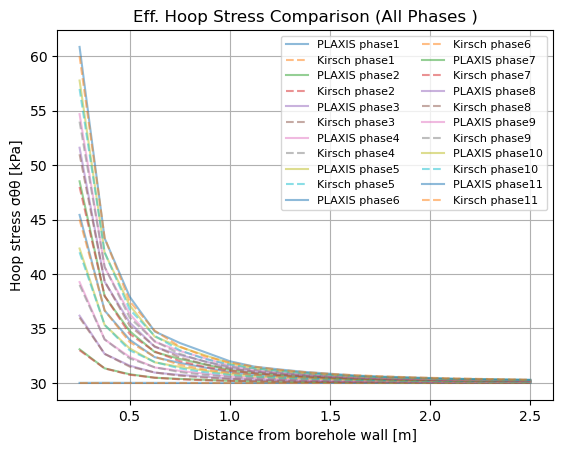

In [5]:
plt.figure()

for phase in phase_names:
    df = results[phase]

    plt.plot(df['r'], df['sig_tt_plx'], alpha=0.5, label=f'PLAXIS {phase}') # just for now as plaxis is unsaturated
    plt.plot(df['r'], df['sig_tt_k'], '--', alpha=0.5, label=f'Kirsch {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Hoop stress σθθ [kPa]')
plt.title('Eff. Hoop Stress Comparison (All Phases )')
plt.legend(ncol=2, fontsize=8)
plt.grid()

# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_hoop_stress_comparison_all.png", dpi=300, bbox_inches='tight')

plt.show()

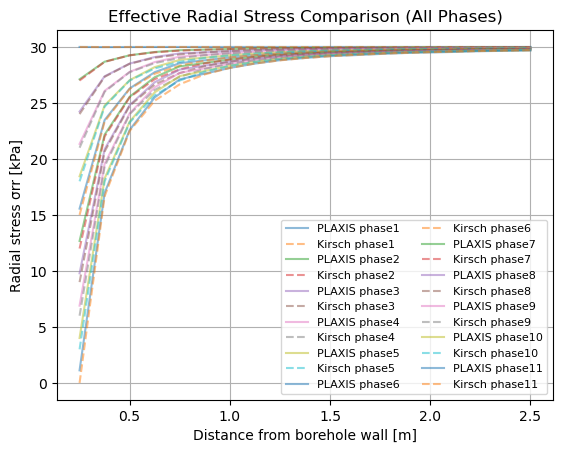

In [6]:
plt.figure()

for phase in phase_names:
    df = results[phase]
    plt.plot(df['r'], df['sig_rr_plx'], alpha=0.5, label=f'PLAXIS {phase}')
    plt.plot(df['r'], df['sig_rr_k'], '--', alpha=0.5, label=f'Kirsch {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Radial stress σrr [kPa]')
plt.title('Effective Radial Stress Comparison (All Phases)')
plt.legend(ncol=2, fontsize=8)
plt.grid()
# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_radial_stress_comparison_all.png", dpi=300, bbox_inches='tight')
plt.show()

Shear stress is negligible. The shear stress giving is so low that it most probably is an error/glitch in PLAXIS.


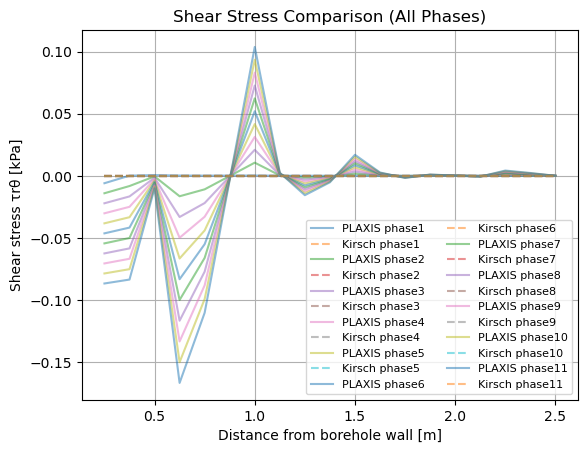

In [7]:
print("Shear stress is negligible. The shear stress giving is so low that it most probably is an error/glitch in PLAXIS.")
plt.figure()

for phase in phase_names:
    df = results[phase]
    plt.plot(df['r'], df['tau_rt_plx'], alpha=0.5, label=f'PLAXIS {phase}')
    plt.plot(df['r'], df['tau_rt_k'], '--', alpha=0.5, label=f'Kirsch {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Shear stress τrθ [kPa]')
plt.title('Shear Stress Comparison (All Phases)')
plt.legend(ncol=2, fontsize=8)
plt.grid()
# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_shear_stress_comparison_all.png", dpi=300, bbox_inches='tight')
plt.show()

[1, 6, 11]


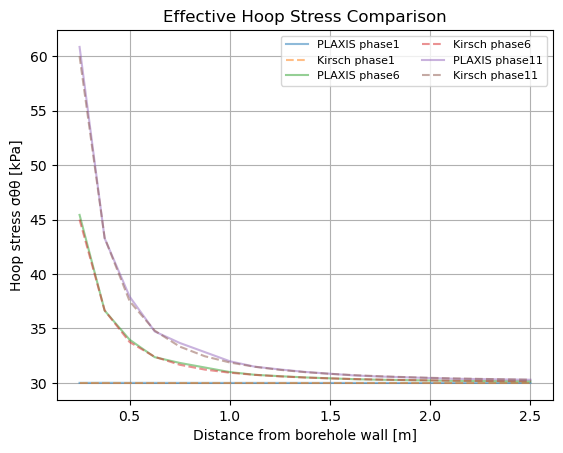

In [8]:
show = [1, 6, 11]
print(show)

plt.figure()

for num in show:
    phase = f'phase{num}'
    df = results[phase]

    plt.plot(df['r'], df['sig_tt_plx'], alpha=0.5, label=f'PLAXIS {phase}')
    plt.plot(df['r'], df['sig_tt_k'], '--', alpha=0.5, label=f'Kirsch {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Hoop stress σθθ [kPa]')
plt.title('Effective Hoop Stress Comparison')
plt.legend(ncol=2, fontsize=8)
plt.grid()
# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_hoop_stress_comparison_3.png", dpi=300, bbox_inches='tight')
plt.show()

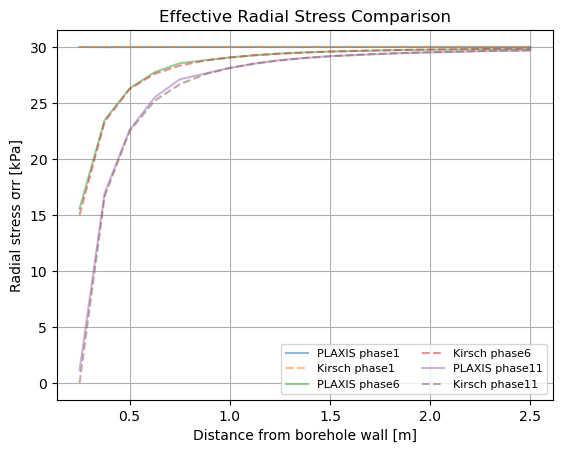

In [9]:
plt.figure()

for num in show:
    phase = f'phase{num}'
    df = results[phase]
    plt.plot(df['r'], df['sig_rr_plx'], alpha=0.5, label=f'PLAXIS {phase}')
    plt.plot(df['r'], df['sig_rr_k'], '--', alpha=0.5, label=f'Kirsch {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Radial stress σrr [kPa]')
plt.title('Effective Radial Stress Comparison')
plt.legend(ncol=2, fontsize=8)
plt.grid()
# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_radial_stress_comparison_3.png", dpi=300, bbox_inches='tight')
plt.show()

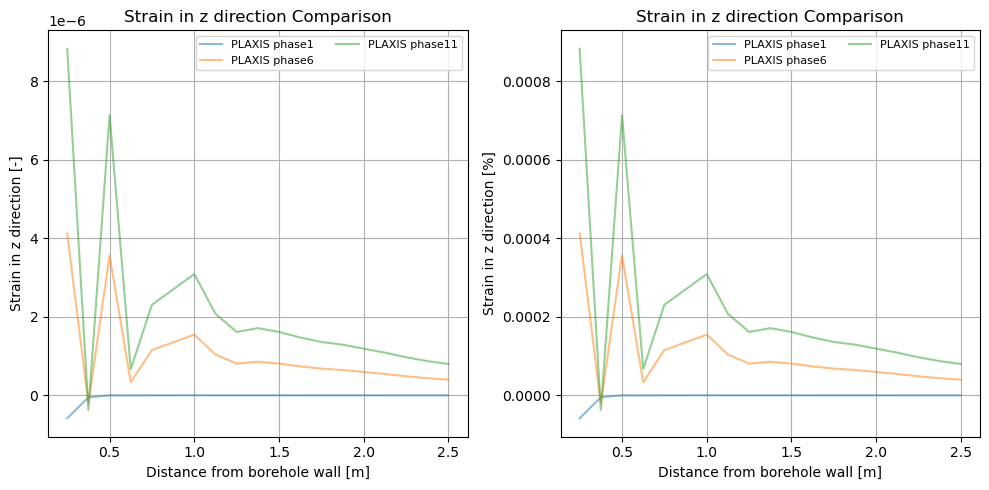

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
for num in show:
    phase = f'phase{num}'
    df = results[phase]
    plt.plot(df['r'], df['epsz'], alpha=0.5, label=f'PLAXIS {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Strain in z direction [-]')
plt.title('Strain in z direction Comparison')
plt.legend(ncol=2, fontsize=8)
plt.grid()

plt.subplot(1, 2, 2)
for num in show:
    phase = f'phase{num}'
    df = results[phase]
    plt.plot(df['r'], df['epsz'] * 100, alpha=0.5, label=f'PLAXIS {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Strain in z direction [%]')
plt.title('Strain in z direction Comparison')
plt.legend(ncol=2, fontsize=8)
plt.grid()

plt.tight_layout()
# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_strain_comparison_3z.png", dpi=300, bbox_inches='tight')
plt.show()

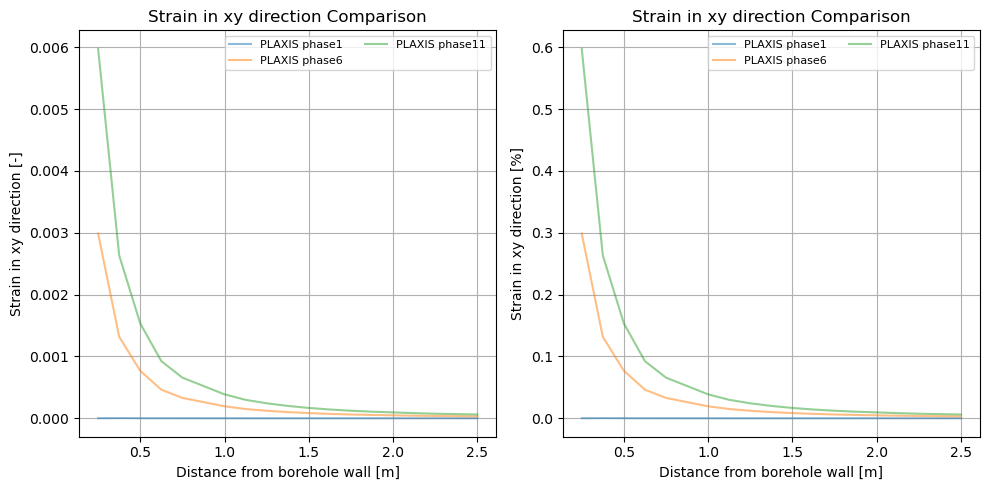

In [11]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)

for num in show:
    phase = f'phase{num}'
    df = results[phase]
    plt.plot(df['r'], df['epsxy'], alpha=0.5, label=f'PLAXIS {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Strain in xy direction [-]')
plt.title('Strain in xy direction Comparison')
plt.legend(ncol=2, fontsize=8)
plt.grid()



plt.subplot(1, 2, 2)
for num in show:
    phase = f'phase{num}'
    df = results[phase]
    plt.plot(df['r'], df['epsxy'] * 100, alpha=0.5, label=f'PLAXIS {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Strain in xy direction [%]')
plt.title('Strain in xy direction Comparison')
plt.legend(ncol=2, fontsize=8)
plt.grid()

# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_strain_comparison_3xy.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

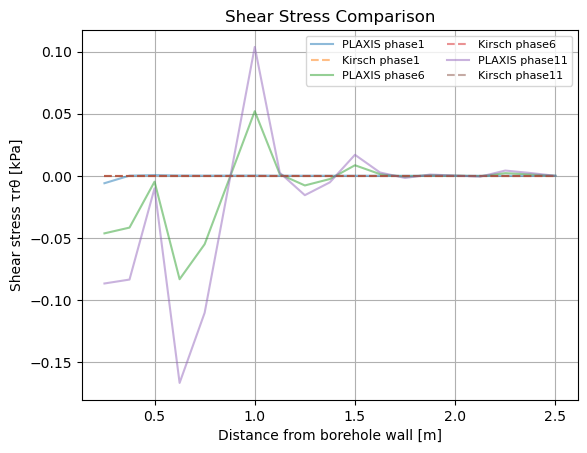

In [12]:
plt.figure()

for num in show:
    phase = f'phase{num}'
    df = results[phase]
    plt.plot(df['r'], df['tau_rt_plx'], alpha=0.5, label=f'PLAXIS {phase}')
    plt.plot(df['r'], df['tau_rt_k'], '--', alpha=0.5, label=f'Kirsch {phase}')

plt.xlabel('Distance from borehole wall [m]')
plt.ylabel('Shear stress τrθ [kPa]')
plt.title('Shear Stress Comparison')
plt.legend(ncol=2, fontsize=8)
plt.grid()
# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\eff_shear_stress_comparison_3.png", dpi=300, bbox_inches='tight')
plt.show()